In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "csvs").exists())
OUTPUT = ROOT / "Notebooks/exp_gene_perturb/gene_bootstrap_pearson.svg"
PIGMENT_GENES = {
    "ENSDARG00000036292": "CDX4", "ENSDARG00000042826": "EGR2B",
    "ENSDARG00000021032": "FOXD3", "ENSDARG00000104566": "FOXI1",
    "ENSDARG00000008305": "HAND2", "ENSDARG00000008174": "HOXB1A",
    "ENSDARG00000017121": "MAFBA", "ENSDARG00000021201": "NOTO",
    "ENSDARG00000007406": "PHOX2A", "ENSDARG00000031891": "TBX1",
    "ENSDARG00000007329": "TBX16", "ENSDARG00000101576": "TBXTA",
    "ENSDARG00000059279": "TFAP2A",
}


In [2]:
def experimental(file, cell_type):
    table = pd.read_csv(ROOT / file)
    row = table.set_index(table.columns[0]).loc[cell_type]
    frame = row.rename("experimental").rename_axis("condition").reset_index()
    frame["Gene"] = frame["condition"].str.replace(r"-mut$", "", regex=True).str.upper()
    return frame[~frame["Gene"].str.contains("-")].groupby("Gene", as_index=False)["experimental"].mean()


def bootstrap(frame, rng, repeats=10_000):
    values = frame[["in_silico", "experimental"]].to_numpy()
    correlations = []
    for _ in range(repeats):
        sample = values[rng.integers(len(values), size=len(values))]
        if sample[:, 0].std() and sample[:, 1].std():
            correlations.append(np.corrcoef(sample.T)[0, 1])
    return np.asarray(correlations)


notochord_sim = pd.read_csv(
    ROOT / "csvs/Zebrafish_insilico_perturbation/notochord_large_scale_gene_perturbation.csv",
    usecols=["Gene", "Notochord_LogFC"],
).rename(columns={"Notochord_LogFC": "in_silico"})
notochord_sim["Gene"] = notochord_sim["Gene"].replace({"TA": "TBXTA"})
notochord = notochord_sim.merge(
    experimental("csvs/Zebrafish_exp_perturbations/abundance_log2fc_24hpf.csv", "notochord")
)

melanophore_sim = pd.read_csv(
    ROOT / "csvs/Zebrafish_insilico_perturbation/pigment_gene_ko_results.csv",
    usecols=["Gene", "Mel_LogFC"],
).rename(columns={"Mel_LogFC": "in_silico"})
melanophore_sim["Gene"] = melanophore_sim["Gene"].map(PIGMENT_GENES)
melanophore = melanophore_sim.merge(
    experimental("csvs/Zebrafish_exp_perturbations/abundance_log2fc_48hpf.csv", "melanophore")
)


In [3]:
from scipy.stats import norm, t
import matplotlib.patheffects as path_effects

FIGURE_DIR = ROOT / "Notebooks/exp_gene_perturb/publication_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "Notochord\n24 hpf": "#3B6FB6",
    "Melanophore\n48 hpf": "#D9792B",
}

comparisons = {
    "Notochord\n24 hpf": notochord,
    "Melanophore\n48 hpf": melanophore,
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "svg.fonttype": "none",  # Preserve SVG labels as editable text.
    "pdf.fonttype": 42,
})


def clean_comparison(frame):
    """Return finite, paired experimental and in-silico observations."""
    required = {"Gene", "in_silico", "experimental"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    clean = frame.dropna(subset=["in_silico", "experimental"]).copy()
    finite = np.isfinite(
        clean[["in_silico", "experimental"]].to_numpy(dtype=float)
    ).all(axis=1)
    clean = clean.loc[finite].reset_index(drop=True)

    if len(clean) < 3:
        raise ValueError("At least three paired observations are required.")

    return clean


def padded_limits(values, fraction=0.12):
    """Data-driven limits with enough room for point and gene labels."""
    values = np.asarray(values, dtype=float)
    span = np.ptp(values)
    if span == 0:
        span = max(abs(values[0]), 1.0)
    padding = fraction * span
    return values.min() - padding, values.max() + padding


def fisher_correlation_ci(r, n, confidence=0.95):
    """Fisher r-to-z confidence interval for a Pearson correlation."""
    if n <= 3:
        raise ValueError("Fisher correlation intervals require n > 3.")
    if not 0 < confidence < 1:
        raise ValueError("confidence must be between 0 and 1.")

    epsilon = np.finfo(float).eps
    clipped_r = np.clip(r, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(clipped_r)
    standard_error = 1 / np.sqrt(n - 3)
    critical_value = norm.ppf(0.5 + confidence / 2)
    lower_z = fisher_z - critical_value * standard_error
    upper_z = fisher_z + critical_value * standard_error
    return tuple(np.tanh([lower_z, upper_z]))


comparisons = {
    name: clean_comparison(frame)
    for name, frame in comparisons.items()
}


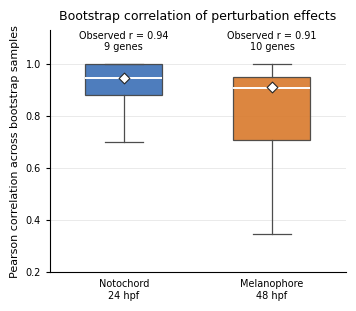

In [4]:
rng = np.random.default_rng(42)
bootstraps = {
    name: bootstrap(frame, rng)
    for name, frame in comparisons.items()
}
observed = {
    name: frame[["in_silico", "experimental"]].corr().iloc[0, 1]
    for name, frame in comparisons.items()
}

fig, ax = plt.subplots(figsize=(3.6, 3.15))

boxplot = ax.boxplot(
    [bootstraps[name] for name in comparisons],
    tick_labels=list(comparisons),
    widths=0.52,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "white", "linewidth": 1.4},
    whiskerprops={"color": "0.3", "linewidth": 0.9},
    capprops={"color": "0.3", "linewidth": 0.9},
)

lower_whiskers = []
for patch, (name, values) in zip(boxplot["boxes"], bootstraps.items()):
    patch.set_facecolor(COLORS[name])
    patch.set_edgecolor("0.25")
    patch.set_linewidth(0.9)
    patch.set_alpha(0.9)

    q1, q3 = np.percentile(values, [25, 75])
    lower_fence = q1 - 1.5 * (q3 - q1)
    lower_whiskers.append(values[values >= lower_fence].min())

plot_floor = np.floor((min(lower_whiskers) - 0.05) * 10) / 10
plot_floor = max(-1.0, plot_floor)
ax.set_ylim(plot_floor, 1.13)

for position, (name, frame) in enumerate(comparisons.items(), start=1):
    r = observed[name]
    ax.scatter(
        position,
        r,
        s=30,
        marker="D",
        facecolor="white",
        edgecolor="0.15",
        linewidth=0.8,
        zorder=4,
    )
    ax.text(
        position,
        1.085,
        f"Observed r = {r:.2f}\n{len(frame)} genes",
        ha="center",
        va="center",
        fontsize=7,
        linespacing=1.15,
    )

ax.set_ylabel("Pearson correlation across bootstrap samples")
ax.set_title("Bootstrap correlation of perturbation effects", pad=7)
ax.yaxis.grid(True, color="0.9", linewidth=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", length=0, pad=5)

fig.tight_layout()

output = FIGURE_DIR / "gene_bootstrap_pearson"
fig.savefig(output.with_suffix(".svg"), bbox_inches="tight", facecolor="white")
fig.savefig(
    output.with_suffix(".png"),
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


In [5]:
GENE_LABEL_POSITIONS = {
    "notochord_logfc_comparison": {
        "CDX4": (-0.83, 0.78, "center"),
        "EGR2B": (-0.22, 0.31, "right"),
        "HAND2": (-0.22, -0.07, "right"),
        "HOXB1A": (-0.22, 0.69, "right"),
        "MAFBA": (0.12, 0.63, "left"),
        "NOTO": (-1.53, -3.50, "left"),
        "TBXTA": (-2.25, -5.72, "left"),
        "TBX1": (-0.22, 1.00, "right"),
        "TBX16": (0.12, 0.18, "left"),
    },
    "melanophore_logfc_comparison": {
        "TFAP2A": (-1.04, -2.54, "left"),
        "FOXD3": (0.15, 1.04, "right"),
        "EGR2B": (-0.11, -0.50, "right"),
        "FOXI1": (0.07, -0.78, "left"),
        "HAND2": (-0.11, 0.04, "right"),
        "HOXB1A": (-0.11, -0.17, "right"),
        "MAFBA": (0.07, 0.57, "left"),
        "NOTO": (0.07, 0.02, "left"),
        "PHOX2A": (-0.11, 0.40, "right"),
        "TBX1": (-0.11, 0.64, "right"),
    },
}


def plot_logfc_comparison(frame, title, color, output_name):
    """Plot paired in-silico and experimental logFC values."""
    frame = clean_comparison(frame)

    # In-silico predictions are the explanatory variable; experiments are
    # the response against which those predictions are evaluated.
    x = frame["in_silico"].to_numpy(dtype=float)
    y = frame["experimental"].to_numpy(dtype=float)
    n = len(frame)
    r = np.corrcoef(x, y)[0, 1]
    fisher_lower, fisher_upper = fisher_correlation_ci(r, n, confidence=0.95)

    x_limits = padded_limits(x, fraction=0.15)
    y_limits = padded_limits(y, fraction=0.12)
    x_grid = np.linspace(x.min(), x.max(), 300)

    fig, ax = plt.subplots(figsize=(3.7, 3.45))

    # Ordinary least-squares fit, shown only over the observed x-range.
    slope, intercept = np.polyfit(x, y, deg=1)
    fitted = intercept + slope * x_grid
    fit_line, = ax.plot(
        x_grid,
        fitted,
        color=color,
        linewidth=1.5,
        zorder=2,
    )

    residuals = y - (intercept + slope * x)
    degrees_freedom = n - 2
    sxx = np.sum((x - x.mean()) ** 2)
    if degrees_freedom > 0 and sxx > 0:
        residual_variance = np.sum(residuals**2) / degrees_freedom
        standard_error = np.sqrt(
            residual_variance
            * (1 / n + (x_grid - x.mean()) ** 2 / sxx)
        )
        confidence_interval = t.ppf(0.975, degrees_freedom) * standard_error
        ax.fill_between(
            x_grid,
            fitted - confidence_interval,
            fitted + confidence_interval,
            color=color,
            alpha=0.14,
            linewidth=0,
            zorder=0,
        )

    # Identity is drawn only where x and y ranges overlap.
    identity_start = max(x_limits[0], y_limits[0])
    identity_end = min(x_limits[1], y_limits[1])
    if identity_start < identity_end:
        ax.plot(
            [identity_start, identity_end],
            [identity_start, identity_end],
            color="0.45",
            linewidth=0.8,
            linestyle=(0, (3, 2)),
            zorder=1,
        )

    ax.scatter(
        x,
        y,
        s=30,
        facecolor=color,
        edgecolor="white",
        linewidth=0.7,
        alpha=0.95,
        zorder=3,
    )

    label_positions = GENE_LABEL_POSITIONS[output_name]
    for _, row in frame.iterrows():
        label_x, label_y, alignment = label_positions[str(row["Gene"])]
        label = ax.annotate(
            str(row["Gene"]),
            (row["in_silico"], row["experimental"]),
            xytext=(label_x, label_y),
            textcoords="data",
            ha=alignment,
            va="center",
            fontsize=6.0,
            color="0.18",
            zorder=4,
            clip_on=False,
            arrowprops={
                "arrowstyle": "-",
                "color": "0.55",
                "linewidth": 0.45,
                "shrinkA": 1.5,
                "shrinkB": 2.5,
            },
        )
        label.set_path_effects([
            path_effects.withStroke(linewidth=1.8, foreground="white")
        ])

    ax.axhline(0, color="0.78", linewidth=0.7, zorder=-1)
    ax.axvline(0, color="0.78", linewidth=0.7, zorder=-1)
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)

    ax.text(
        0.04,
        0.96,
        f"Pearson r = {r:.2f}\n"
        f"95% Fisher CI [{fisher_lower:.2f}, {fisher_upper:.2f}]\n"
        f"{n} genes",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=7,
    )
    ax.text(
        0.97,
        0.05,
        "Solid: linear fit\nDashed: identity",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=6.2,
        color="0.35",
        linespacing=1.25,
    )

    ax.set_xlabel("In-silico predicted logFC")
    ax.set_ylabel("Experimental logFC")
    ax.set_title(title, pad=7)
    ax.grid(True, color="0.93", linewidth=0.55)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    fig.tight_layout()

    output = FIGURE_DIR / output_name
    fig.savefig(output.with_suffix(".svg"), bbox_inches="tight", facecolor="white")
    fig.savefig(
        output.with_suffix(".png"),
        dpi=600,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()


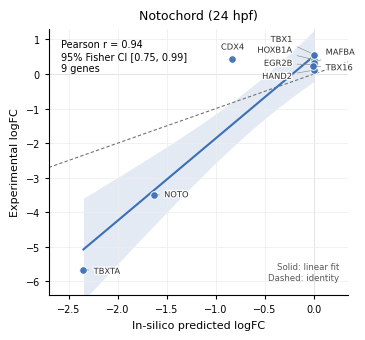

In [6]:
plot_logfc_comparison(
    frame=comparisons["Notochord\n24 hpf"],
    title="Notochord (24 hpf)",
    color=COLORS["Notochord\n24 hpf"],
    output_name="notochord_logfc_comparison",
)


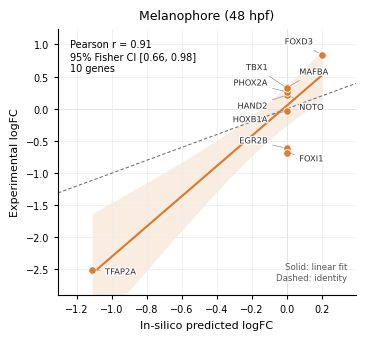

In [7]:
plot_logfc_comparison(
    frame=comparisons["Melanophore\n48 hpf"],
    title="Melanophore (48 hpf)",
    color=COLORS["Melanophore\n48 hpf"],
    output_name="melanophore_logfc_comparison",
)
